# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [183]:
STUDENT_NAME = "Nguyễn Thị Ánh Tuyết"  # TODO: Họ và tên
STUDENT_ID = "25122048"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Thị Ánh Tuyết (25122048)


In [184]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: F:\MLIoT2026\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [185]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [186]:
# TODO N1

shifted_logits = logits - logits.max(axis = 1, keepdims = True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis = 1, keepdims = 1)
predicted_classes = np.argmax(class_probabilities, axis = 1)
confidence_scores = np.max(class_probabilities, axis = 1)

In [187]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [188]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [189]:
# TODO N2
train_feature_mean = X_train.mean(axis = 0) 
train_feature_std = X_train.std(axis = 0) 
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [190]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [191]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [192]:
# TODO N3
correct_mask = true_labels == predicted_classes
high_confidence_mask = (predicted_classes >= confidence_threshold)
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0] 

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [193]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [194]:
# TODO N4
normalized_batch = image_batch_uint8.astype('float32') / 255.0
augmented_batch = np.flip(normalized_batch, axis = 2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho các tính chất của xe và giá xe tương ứng
2. ?
3. Mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [195]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum() 

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [196]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [197]:
# TODO D2
df_clean = pd.DataFrame.replace(raw_df, '?', np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column]  = pd.to_numeric(df_clean[column])
    
missing_by_column = df_clean.isna().sum() 

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Vì mỗi numeric feature thể hiện một đặc tính, ý nghĩa khác nhau, giá trị phân bổ(mean, std, median) cũng không giống nhau, việc fill bằng cùng một giá trị sẽ không nói lên được tính chất của features đó.
- Với `price` nên lựa chọn drop. Vì mặc dù chỉ có 4 missing values trên tổng số 205 điểm dữ liệu (<10%), nhưng `price` là targe variable nên việc fill cho variable này sẽ khiến mô hình học thông tin sai lệch.
- Do cột này miss 41/205 (20%) dữ liệu, nên việc lựa chọn fill hay drop cần cân nhắc. Vì nếu ta drop 20% điểm dữ liệu này ta sẽ mất đi rất nhiều thông tin trong dataset, hay việc xoá luôn feature này có thể sẽ làm mất đi một số thông tin quan trọng trong việc dự đoán `price`. Ngược lại nếu fill bằng mean/median sẽ làm sai lệch thông tin dữ liệu (dữ liệu bị phình to ra ở giữa khi biểu điễn bằng histogram).


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [198]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [199]:
# TODO D3
analysis_df = pd.DataFrame.dropna(df_clean, axis = 0, how = 'any', subset = AUTO_FEATURES)[AUTO_FEATURES]
X_auto = analysis_df.to_numpy(dtype = 'float64')
auto_feature_mean = X_auto.mean(axis = 0, keepdims = True)
auto_feature_std = X_auto.std(axis = 0, keepdims = True)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [200]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z > 2)
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [201]:
# TODO D5

engine_price_corr = np.corrcoef(analysis_df['engine_size'], analysis_df['price'])[0, 1]
price_by_body_style = pd.DataFrame.groupby(df_clean, by = df_clean['body_style'])['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

Text(0.5, 1.0, 'Histogram/KDE cua price')

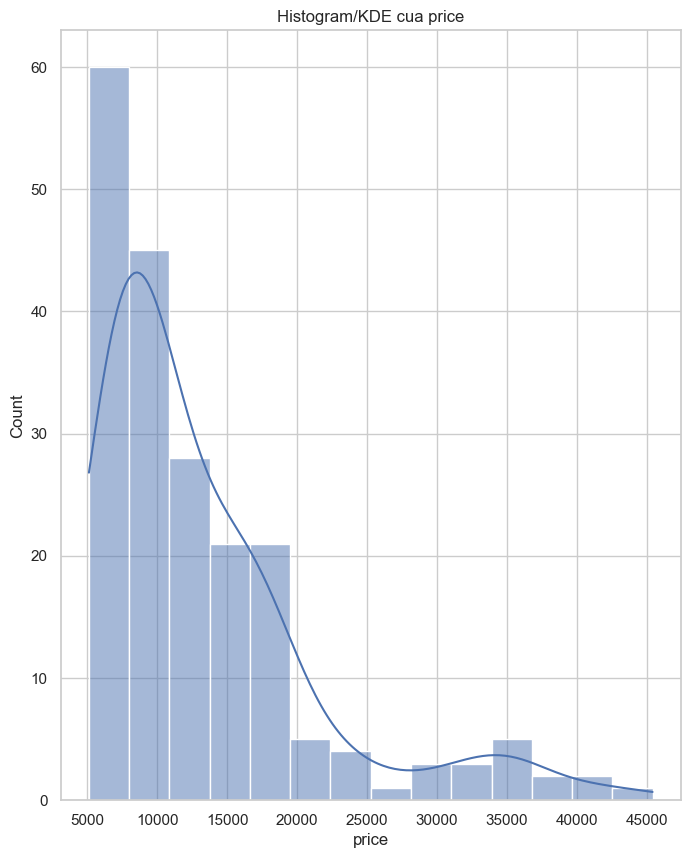

In [202]:
# TODO M2.1: histogram/KDE của price
# print(df_clean.isna().sum())
fig, ax = plt.subplots(figsize = (8, 10))
sns.histplot(data = df_clean, x = 'price', kde =True)
ax.set_title('Histogram/KDE cua price')

**Nhận xét:** Phân phối của price lệch phải cho thấy các mẫu xe tập trung trong phân khúc giá từ phổ thông đến tầm trung (5000 -> 20000) và số lượng ít xe ở phân khúc cao cấp(30000 -> 45000). Giá trị của mean > median do các điểm dữ liệu cao bất thường ở phân khúc giá cao.

## M2.2 Dataset có cân bằng theo body style không?

Text(0.5, 1.0, 'Countplot cua Body Style')

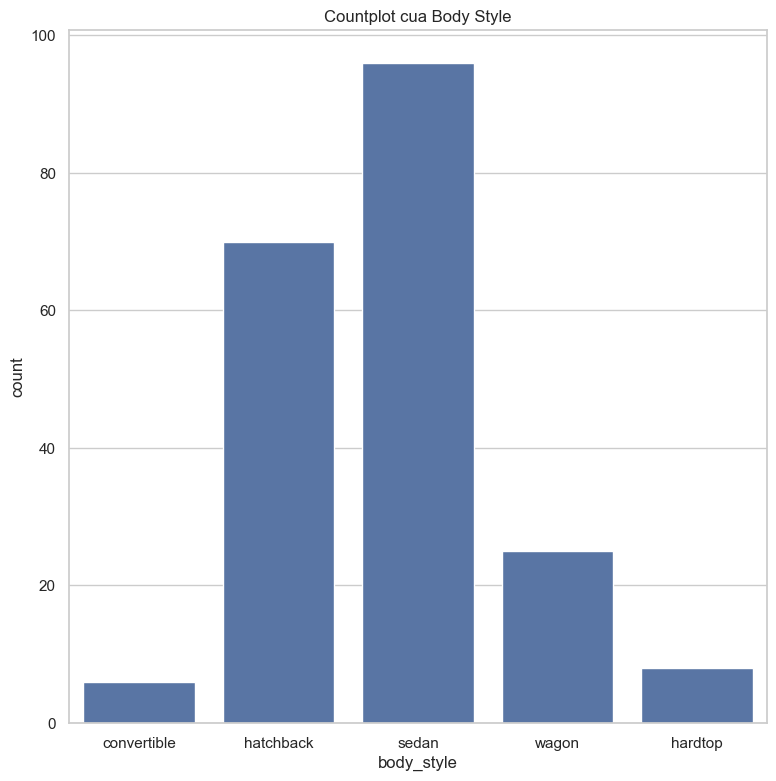

In [203]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize = (9, 9))
# plt.subplots?
# sns.countplot
sns.countplot(data = df_clean, x = 'body_style')
ax.set_title('Countplot cua Body Style')

**Nhận xét:** Dữ liệu không cân bằng theo body_style. Chủ yếu tập trung ở hatchback và segan, số ít ở wagon và hardtop và contertible rất hiếm.

## M2.3 Price khác nhau theo body style ra sao?

Text(0.5, 1.0, 'Price theo Body Style')

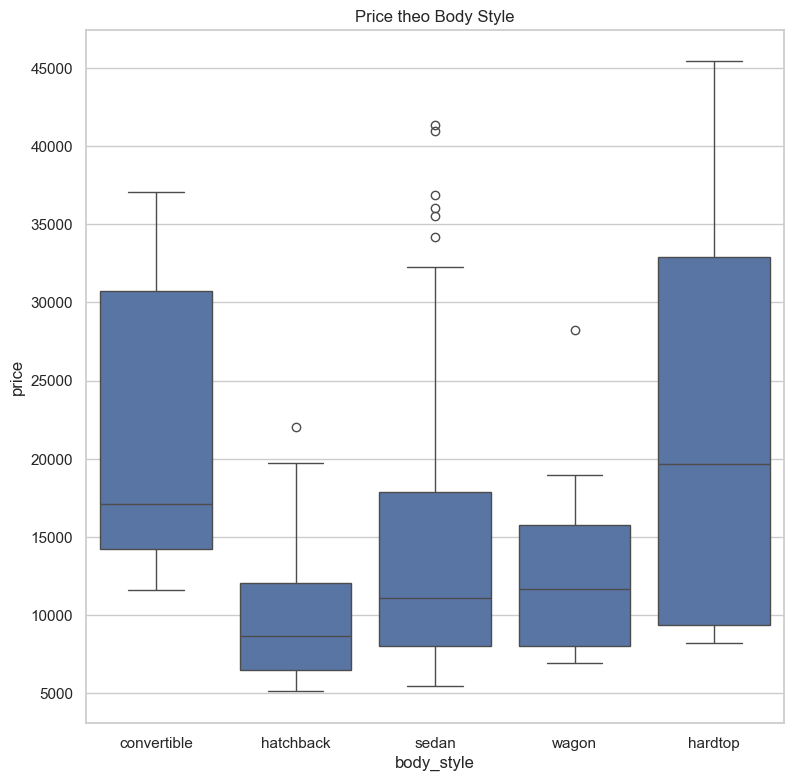

In [204]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize = (9, 9))
sns.boxplot(data = df_clean, x = 'body_style', y = 'price')
ax.set_title('Price theo Body Style')

**Nhận xét:**
- Convertible: Có phân khúc giá nằm trong khoảng tầm trung (15000 - 30000), sô ít ở cao cấp (>30000)
- Hatchback, segan, wagon: Có phân khúc nằm trong khoảng phổ thông (<= 15000) và số ít ở tầm trung (>15000). Dòng xe phân khúc cao cấp tập trung chủ yếu ở sedan, đây cũng là cái điểm outliers trong của dòng xe này.
- Hardtop: Phân khúc giá trải đều từ phổ thông đến cao cấp

## M2.4 Engine size liên quan thế nào tới price?

<Axes: xlabel='engine_size', ylabel='price'>

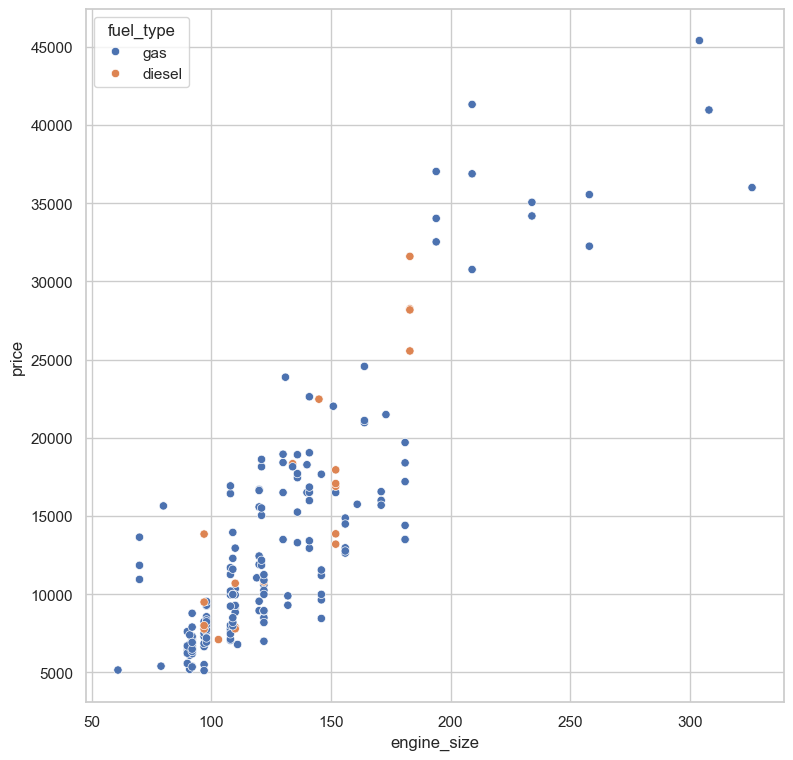

In [205]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize = (9, 9))
sns.scatterplot(data = df_clean, x = 'engine_size', y = 'price', hue = 'fuel_type')

**Nhận xét:**
- Engine size tỷ lệ tương quan dương khá cao với price, khi mà engine_size tăng thì price tăng và ngược lại. 
- Với những engine_size kết hợp với fuel_type là diesel thì price sẽ nhỉng hơn so với gas khi so sánh ở cùng engine_size. Việc sử dụng fuel_type là diesel khá ít.
- Outliers là các xe có engine_size (> 250) lớn do đó kéo theo price lớn (>300).

## M2.5 Các feature numeric tương quan ra sao?

<Axes: >

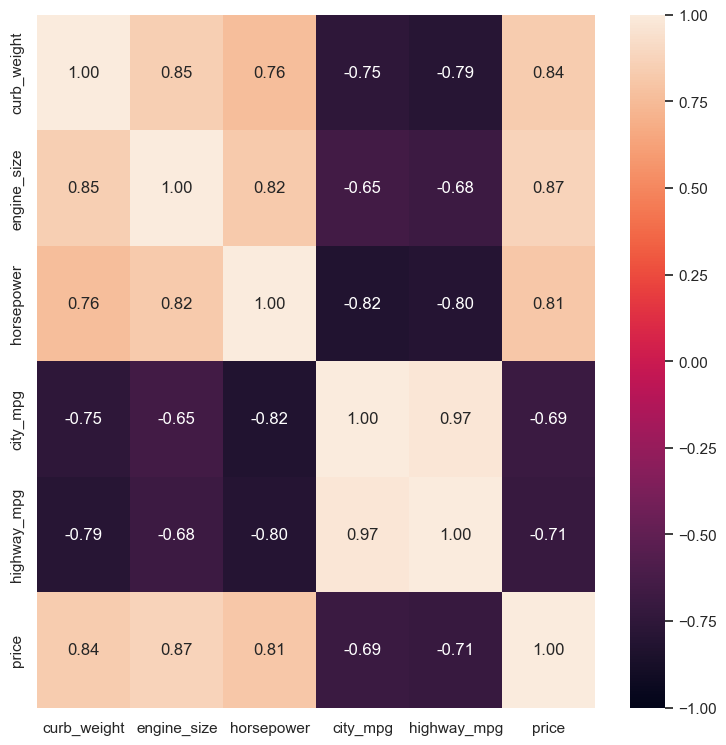

In [206]:
# TODO M2.5: correlation heatmap
corr_matrix = analysis_df.corr()
fig, ax = plt.subplots(figsize = (9, 9))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', vmin = -1, vmax = 1)
# sns.heatmap?

**Nhận xét:**
- Độ tương quan giữa các numeric features và price khá cao với abs thấp nhất là 0.69 ở city_mpg và cao nhất là 0.87 ở engine_size. city_mpg và highway_mpg tương quan nghịch với price.
- Đồng thời độ tương quan giữa các features với nhau cũng khá cao và rất cao, với abs thấp nhất là 0.65 ở(city_mpg, engine_size) và cao nhất là 0.97 ở (highway_mpg, city_mpg). Các features có mullinearity khá cao.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

C:\Users\cuctu\AppData\Local\Temp\ipykernel_22844\2663628702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='drive_wheels', y='price', palette='muted')


Text(0.5, 1.0, 'Phân phối Giá xe theo Hệ dẫn động')

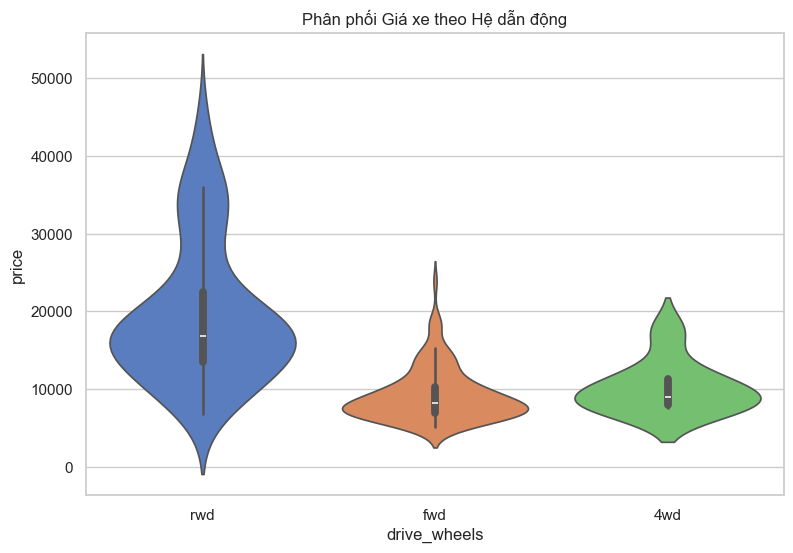

In [207]:
# TODO M2.6
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=df_clean, x='drive_wheels', y='price', palette='muted')
ax.set_title('Phân phối Giá xe theo Hệ dẫn động')

**Nhận xét:** 
- rwd: price phân bố rộng từ 0 -> 50000, tập trung chủ yếu từ 15000 - 25000, có median cao nhất.
- fwd, 4wd: phân bố hẹp tập trung chủ yếu ở phân khúc phổ thông (<15000) và một ít ở phân khúc tầm trung.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

1. Ba phát hiện chính:
- Phân khúc giá: Phân phối price bị lệch phải, tập trung chủ yếu ở mức 5.000 - 15.000. Phân khúc xe cao cấp (>30.000) chiếm tỷ lệ rất nhỏ.Mất cân bằng dữ liệu: Dòng sedan và hatchback chiếm phần lớn. 
- Trong đó, sedan có phương sai giá cao nhất, chứa nhiều điểm ngoại lai đắt tiền.
- Tương quan mạnh: engine_size là yếu tố dự báo giá tốt nhất (tương quan dương, $r = 0.87$), trong khi tính tiết kiệm nhiên liệu city_mpg kéo giá xuống (tương quan âm, $r = -0.69$).

2. Hai hạn chế của bộ dữ liệu:
- Kích thước mẫu nhỏ: Chỉ có 205 quan sát, dễ gây nhiễu thống kê và dễ bị Overfitting khi huấn luyện mô hình.
- Dữ liệu thiếu hụt: Cột normalized_losses thiếu tới 20% dữ liệu, gây khó khăn cho việc quyết định drop hay fill. Do đó việc lấy z-score <= 2 có thể làm thiếu hụt thông tin hơn.

3. Correlation không đồng nghĩa causation:
- curb_weight tương quan rất mạnh với giá xe ($r = 0.84$). Tuy nhiên, cố tình nhét thêm tạ để xe nặng hơn không làm nó đắt lên. "Biến ẩn" gây ra hiện tượng này là phân khúc xe: xe sang thường được trang bị động cơ to, tiện nghi nhiều nên nặng hơn và chi phí sản xuất đắt hơn.

4. Câu hỏi phân tích tiếp theo: Khi đặt trong cùng một cấu hình dung tích động cơ, sức mạnh thương hiệu (ví dụ: xe châu Âu vs xe Nhật) tạo ra mức chênh lệch giá bán là bao nhiêu?